In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from src.analysis_utils import (
    drop_missing,
    subset_variables,
    recode_vaccination_variables,
    chi2_cramers_v_weighted,
    normalized_crosstab,
    screen_categorical_associations,
    fit_weighted_logit,
    fit_weighted_ordinal_logit,
    extract_odds_ratios,
    plot_heatmap,
    plot_odds_ratios,
    plot_weighted_coverage_bar,
    plot_stacked_vaccination
)

In [2]:
# Path relative to script.py
csv_path = "../data/cleaned_data.csv"

# Read CSV
df = pd.read_csv(csv_path)

# Display first 5 rows
df.head()

,Mothers_id,Birth_Order,Cluster_id,Household_id,Respondents_line_number,v005,Childs_Age,Received_Hep_B_at_birth,Hep_B_1,Hep_B_2,...,hhid,Number_of_household_members,Number_of_children_under_5,Result_of_household_interview,Region,Type_of_place_of_residence,Translator_used,Vaccination_at_Birth,Vaccination_Flag,wt
0,205 12 2,2,205,12,2,552441,14,Vaccination date on card,No,No,...,205 12,4,2,Completed,Kampot,Urban,No,True,None Post Birth,0.552441
1,512 26 7,1,512,26,7,297079,8,Vaccination date on card,No,No,...,512 26,14,3,Completed,Preah Sihanouk,Rural,No,True,None Post Birth,0.297079
2,512 29 5,1,512,29,5,297079,4,No,No,No,...,512 29,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.297079
3,641 16 1,2,641,16,1,64896,21,Vaccination date on card,No,No,...,641 16,3,2,Completed,Kep,Urban,No,True,None Post Birth,0.064896
4,513 6 1,4,513,6,1,287780,32,No,No,No,...,513 6,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.287780


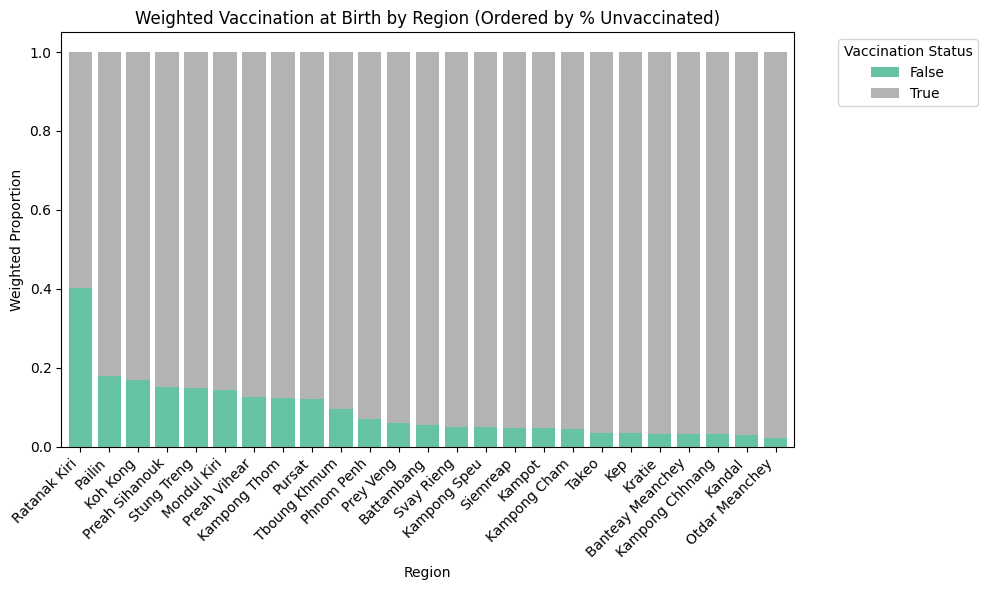

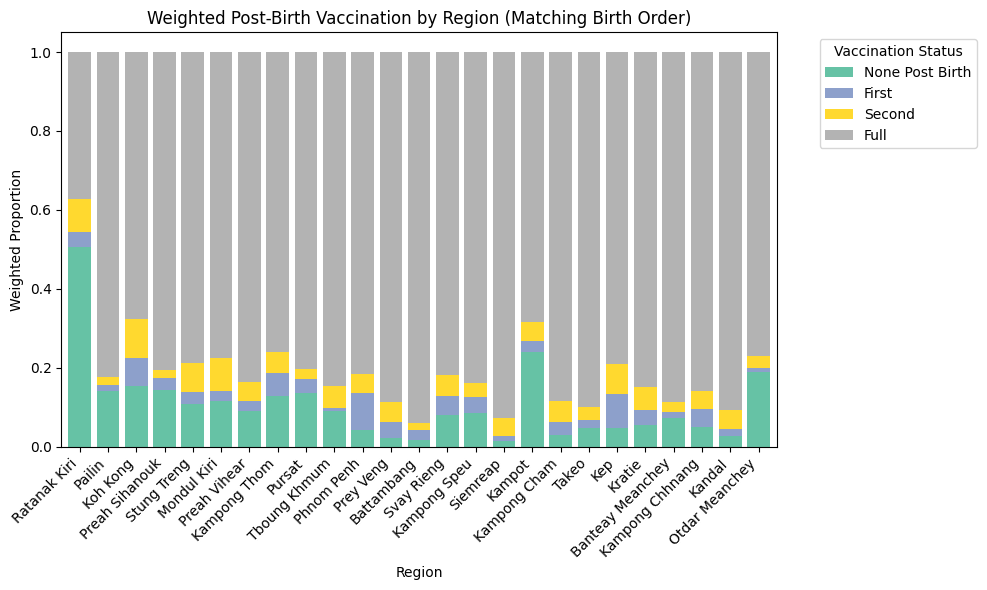

In [3]:
# ---------------------------------------------------
# Vaccination Coverage by Region
# ---------------------------------------------------

vac_df = drop_missing(
    df[["Region", "Vaccination_at_Birth", "Vaccination_Flag", "wt"]].copy(),
    ["Region", "Vaccination_at_Birth", "Vaccination_Flag", "wt"]
)

# Weighted proportions for Vaccination at Birth
table_birth_pct = (
    vac_df.groupby(["Region", "Vaccination_at_Birth"])["wt"]
    .sum()
    .unstack(fill_value=0)
)
table_birth_pct = table_birth_pct.div(table_birth_pct.sum(axis=1), axis=0)

# Weighted proportions for Vaccination Flag
custom_order = ["None Post Birth", "First", "Second", "Full"]
table_post_pct = (
    vac_df.groupby(["Region", "Vaccination_Flag"])["wt"]
    .sum()
    .unstack(fill_value=0)
)
table_post_pct = table_post_pct.div(table_post_pct.sum(axis=1), axis=0)

# Sort by greatest weighted % unvaccinated at birth
false_col = False if False in table_birth_pct.columns else 'False'
if false_col in table_birth_pct.columns:
    table_birth_pct = table_birth_pct.sort_values(by=false_col, ascending=False)
else:
    print(f"Warning: Column {false_col} not found. Available: {list(table_birth_pct.columns)}")

# Align post-birth table to same regional order 
regions = table_birth_pct.index
existing_post_cols = [c for c in custom_order if c in table_post_pct.columns]
table_post_pct = table_post_pct.reindex(index=regions, columns=existing_post_cols).fillna(0)

# ---------------------------------------------------
# Figure 1: Vaccination at Birth
# ---------------------------------------------------
ax1 = table_birth_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', width=0.8)
plt.title("Weighted Vaccination at Birth by Region (Ordered by % Unvaccinated)")
plt.ylabel("Weighted Proportion")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vaccination Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../output/Weighted_vax_at_birth_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------
# Figure 2: Vaccination Flag
# ---------------------------------------------------
ax2 = table_post_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', width=0.8)
plt.title("Weighted Post-Birth Vaccination by Region (Matching Birth Order)")
plt.ylabel("Weighted Proportion")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vaccination Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../output/Weighted_vax_post_birth_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# ---------------------------------------------------
# Rural vs Urban Chi Squared + Cramer V
# ---------------------------------------------------

df = recode_vaccination_variables(df)
df["Residence"] = pd.Categorical(
    df["Type_of_place_of_residence"], categories=["Urban", "Rural"]
)
df_res = drop_missing(df, ["Vaccination_at_Birth", "Vaccination_Flag_ord", "Residence", "wt"])
print("Vaccination at Birth ~ Residence")
stats_birth = chi2_cramers_v_weighted(df_res, "Residence", "Vaccination_at_Birth", "wt")
print(f"Chi-square = {stats_birth['chi2']:.3f}, p = {stats_birth['p_value']:.6f}")
print(f"Cramér's V = {stats_birth['cramers_v']:.3f}")
print("\nVaccination Flag ~ Residence")
stats_flag = chi2_cramers_v_weighted(df_res, "Residence", "Vaccination_Flag_ord", "wt")
print(f"Chi-square = {stats_flag['chi2']:.3f}, p = {stats_flag['p_value']:.6f}")
print(f"Cramér's V = {stats_flag['cramers_v']:.3f}")

# ---------------------------------------------------
# Binary Logistic Rregression: Residence
# ---------------------------------------------------
df_binary_res, fit_stats_binary_res = fit_weighted_logit(
    df=df_res,
    formula="Vaccination_at_Birth ~ Residence",
    weight_col="wt")

print("=== Binary Logit: Odds Ratios ===")
print(df_binary_res)

print("\n=== Binary Logit: Model Fit ===")
for k, v in fit_stats_binary_res.items():
    print(f"  {k}: {v}")
    
# ---------------------------------------------------
# Ordinal Logistic Rregression: Residence
# ---------------------------------------------------
df_ordinal_res, fit_stats_ordinal_res = fit_weighted_ordinal_logit(
    df=df_res,
    outcome="Vaccination_Flag_ord",
    predictors=["Residence"],
    weight_col="wt"
)

print("=== Ordinal Logit: Odds Ratios ===")
print(df_ordinal_res)

print("\n=== Ordinal Logit: Model Fit ===")
for k, v in fit_stats_ordinal_res.items():
    print(f"  {k}: {v}")

Vaccination at Birth ~ Residence
Chi-square = 8.113, p = 0.004395
Cramér's V = 0.041

Vaccination Flag ~ Residence
Chi-square = 26.413, p = 0.000008
Cramér's V = 0.075


C:\Users\oscar\Vaccination_Cambodia\Cambodia_HepB_Project\analysis notebooks\..\src\analysis_utils.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = pd.pivot_table(
C:\Users\oscar\Vaccination_Cambodia\Cambodia_HepB_Project\analysis notebooks\..\src\analysis_utils.py:91: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = pd.pivot_table(
C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str

=== Binary Logit: Odds Ratios ===
                       OR   CI_lower   CI_upper    t_value       p_value
(Intercept)     17.504014  12.772257  23.988752  17.801928  1.045491e-68
ResidenceRural   0.697620   0.493019   0.987128  -2.033150  4.209216e-02

=== Binary Logit: Model Fit ===
  n: 4814
  log_likelihood: -1181.320583830781
  null_log_likelihood: -1185.7276970526434
  mcfadden_r2: 0.0037168004364046547
  aic: 2366.7588342965605
  bic: 2379.5997348982482


C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


=== Ordinal Logit: Odds Ratios ===
                      OR  CI_lower  CI_upper    t_value   p_value
ResidenceRural  0.836405  0.668731  1.046120  -1.565001  0.117583
0|1             0.067367  0.055577  0.081660 -27.480828  0.000000
1|2             0.109619  0.088938  0.135109 -20.725544  0.000000
2|3             0.163608  0.133883  0.199932 -17.696001  0.000000

=== Ordinal Logit: Model Fit ===
  n: 4814
  log_likelihood: -2862.490619158592
  null_log_likelihood: -2864.8641735634797
  mcfadden_r2: 0.0008285050393629367
  aic: 5732.981238317184
  bic: 5758.898372790556


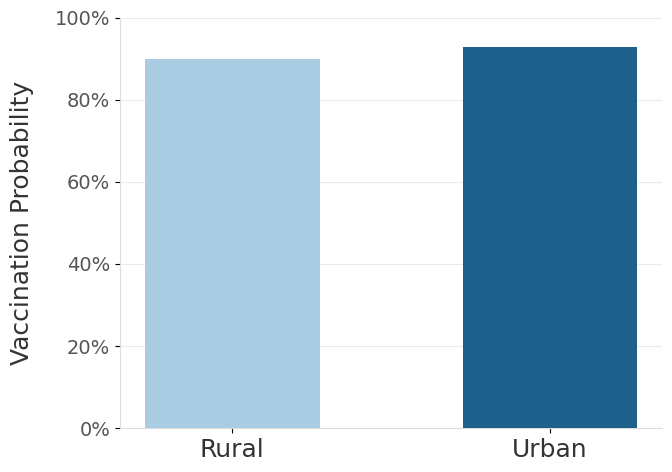

In [6]:
# ---------------------------------------------------
# Modelled Probability of Birth Vaccination by Rural/Urban
# ---------------------------------------------------


    
groups = ['Rural', 'Urban']
probabilities = [0.899, 0.927]

plt.rcParams.update({'font.size': 16, 'font.family': 'sans-serif'})

fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#a9cce3', '#1f618d']
bars = ax.bar(groups, probabilities,
              color=colors,
              edgecolor='none',
              width=0.55,
              zorder=3)

ax.set_ylim(0, 1.0)
ax.set_ylabel('Vaccination Probability', fontsize=18, labelpad=15, color='#333333')
ax.set_xticks([0, 1])
ax.set_xticklabels(groups, fontsize=18, color='#333333')
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=14, color='#555555')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

ax.yaxis.grid(True, linestyle='-', alpha=0.2, color='#999999', zorder=0)
plt.tight_layout()
plt.savefig("../output/Vaccination_prob_rural_urban.png", dpi=300, bbox_inches="tight")
plt.show()

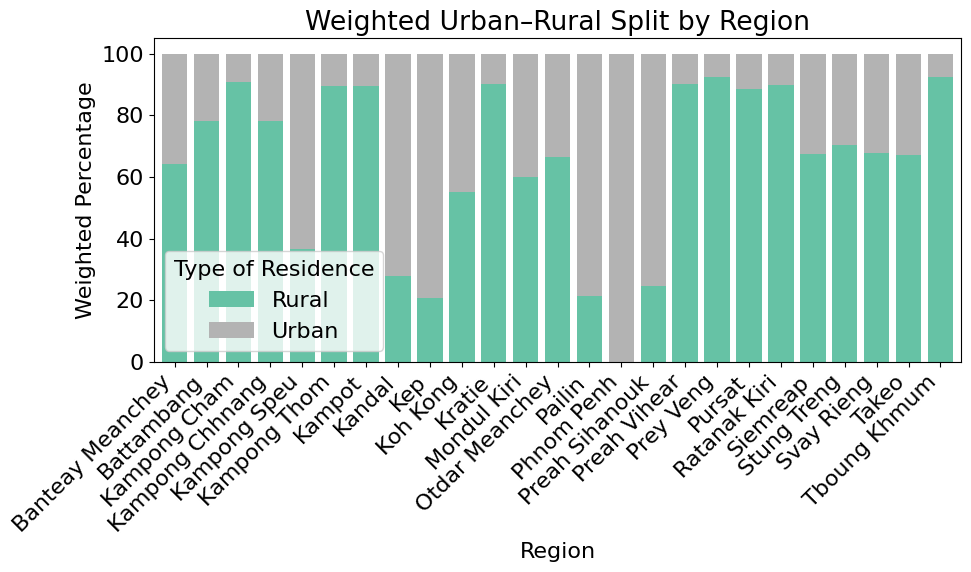

In [7]:
# ---------------------------------------------------
# Urban/Rural Split by Region
# ---------------------------------------------------


region_residence = (
    df.groupby(["Region", "Type_of_place_of_residence"])["wt"]
    .sum()
    .reset_index(name="Weighted_Count")
)
region_residence["Total"] = region_residence.groupby("Region")["Weighted_Count"].transform("sum")
region_residence["Percentage"] = 100 * region_residence["Weighted_Count"] / region_residence["Total"]

table_residence = region_residence.pivot(
    index="Region",
    columns="Type_of_place_of_residence",
    values="Percentage"
)

table_residence.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="Set2",
    width=0.8
)
plt.title("Weighted Urban–Rural Split by Region")
plt.ylabel("Weighted Percentage")
plt.xlabel("Region")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Type of Residence")
plt.tight_layout()
plt.savefig("../output/Urban_rural_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# ---------------------------------------------------
# Vaccination Coverage by Region
# ---------------------------------------------------


df_test = drop_missing(df.copy(), ["Region", "Vaccination_at_Birth", "Vaccination_Flag", "wt"])

# --- Weighted at birth stats by region ---
region_birth = df_test.groupby("Region").apply(
    lambda x: pd.Series({
        "N": len(x),
        "Vaccinated_Pct": round(np.average(x["Vaccination_at_Birth"], weights=x["wt"]) * 100, 1),
        "Not_Vaccinated_Pct": round((1 - np.average(x["Vaccination_at_Birth"], weights=x["wt"])) * 100, 1)
    }),
    include_groups=False
).reset_index()

# --- Weighted post birth stats by region ---
region_postbirth = df_test.groupby("Region").apply(
    lambda x: pd.Series({
        "None_Pct": round(np.average(x["Vaccination_Flag"] == "None Post Birth", weights=x["wt"]) * 100, 1),
        "First_Pct": round(np.average(x["Vaccination_Flag"] == "First", weights=x["wt"]) * 100, 1),
        "Second_Pct": round(np.average(x["Vaccination_Flag"] == "Second", weights=x["wt"]) * 100, 1),
        "Full_Pct": round(np.average(x["Vaccination_Flag"] == "Full", weights=x["wt"]) * 100, 1)
    }),
    include_groups=False
).reset_index()

# --- Merge and sort ---
regional_table = pd.merge(region_birth, region_postbirth, on="Region")
regional_table = regional_table.sort_values("Vaccinated_Pct")
print(regional_table.to_string(index=False))

          Region     N  Vaccinated_Pct  Not_Vaccinated_Pct  None_Pct  First_Pct  Second_Pct  Full_Pct
    Ratanak Kiri 188.0            59.7                40.3      50.7        3.6         8.4      37.3
          Pailin 162.0            82.0                18.0      14.2        1.4         2.1      82.2
        Koh Kong 182.0            83.2                16.8      15.3        7.2         9.9      67.6
  Preah Sihanouk 138.0            84.9                15.1      14.3        3.0         2.2      80.5
     Stung Treng 247.0            85.1                14.9      10.9        3.1         7.2      78.9
     Mondul Kiri 231.0            85.6                14.4      11.4        2.5         8.6      77.5
    Preah Vihear 228.0            87.5                12.5       9.0        2.5         4.8      83.7
    Kampong Thom 215.0            87.7                12.3      12.8        5.8         5.3      76.1
          Pursat 126.0            87.9                12.1      13.6        3.4   

In [9]:
# ---------------------------------------------------
# Vaccination Coverage Regional Outliers
# ---------------------------------------------------


def regional_zscore_screen(
    df,
    category_col,
    region_col="Region",
    weight_col="wt",
    threshold=2.0
):
    """
    Calculates weighted proportions per region and flags
    regions whose z-score exceeds the threshold.
    """
    # --- Weighted proportions per region ---
    counts = (
        df.groupby([region_col, category_col])[weight_col]
        .sum()
        .reset_index(name="Count")
    )
    totals = counts.groupby(region_col)["Count"].sum().reset_index(name="Total")
    counts = counts.merge(totals, on=region_col)
    counts["Proportion"] = counts["Count"] / counts["Total"]

    # --- Z-scores within each category ---
    counts["Mean"] = counts.groupby(category_col)["Proportion"].transform("mean")
    counts["Std"] = counts.groupby(category_col)["Proportion"].transform("std")
    counts["Z_Score"] = (counts["Proportion"] - counts["Mean"]) / counts["Std"]
    counts["Outlier"] = counts["Z_Score"].abs() > threshold

    # --- Summary table ---
    summary = (
        counts[counts["Outlier"]]
        [[region_col, category_col, "Proportion", "Mean", "Z_Score"]]
        .sort_values("Z_Score", key=abs, ascending=False)
        .reset_index(drop=True)
    )

    print(f"Regions with |Z| > {threshold}:")
    print(summary.to_string() if not summary.empty else "No outliers found.")

    return counts, summary


# --- Run for both outcomes ---
counts_birth, outliers_birth = regional_zscore_screen(
    df,
    category_col="Vaccination_at_Birth"
)

counts_flag, outliers_flag = regional_zscore_screen(
    df,
    category_col="Vaccination_Flag"
)

Regions with |Z| > 2.0:
         Region  Vaccination_at_Birth  Proportion      Mean   Z_Score
0  Ratanak Kiri                 False     0.40325  0.091842  3.790632
1  Ratanak Kiri                  True     0.59675  0.908158 -3.790632
Regions with |Z| > 2.0:
         Region Vaccination_Flag  Proportion      Mean   Z_Score
0  Ratanak Kiri  None Post Birth    0.506641  0.105197  3.959807
1  Ratanak Kiri             Full    0.372868  0.809903 -3.882349
2    Phnom Penh            First    0.091663  0.035402  2.535109
3      Koh Kong           Second    0.099375  0.049497  2.329792
4           Kep            First    0.085989  0.035402  2.279407



Outlier screening results:


,Vaccination_at_Birth,Target Proportion,Reference Proportion,p_value,Outlier
0,False,0.405405,0.0618,1.676106e-17,True
1,True,0.594595,0.9382,1.676106e-17,True


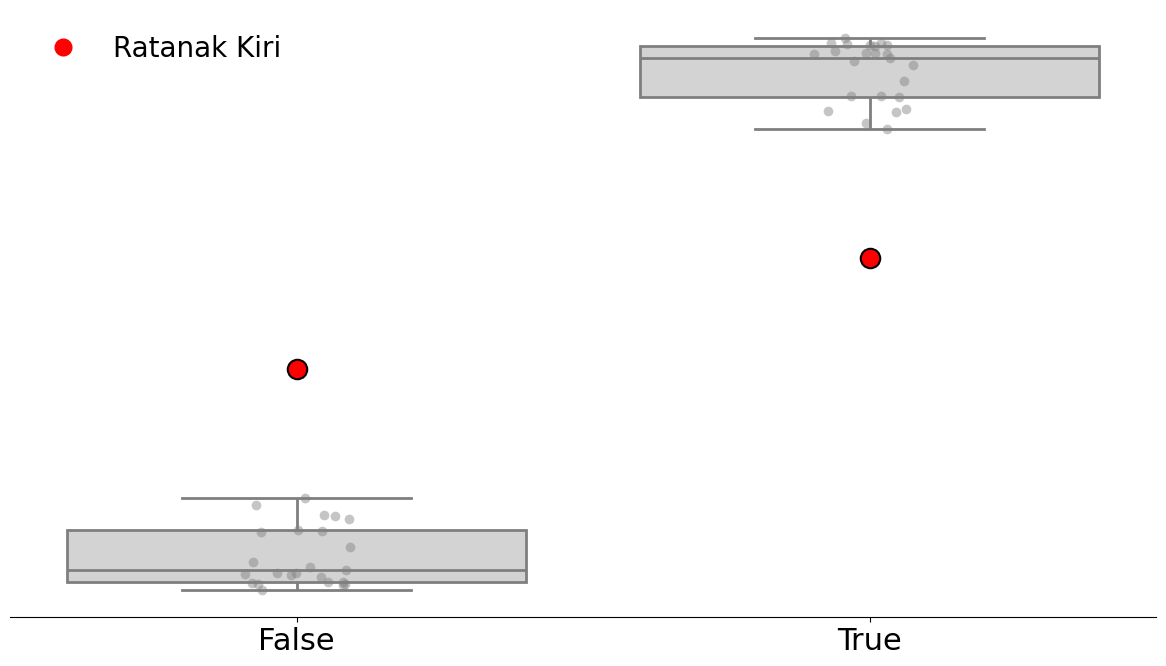


Outlier screening results:


,Vaccination_Flag,Target Proportion,Reference Proportion,p_value,Outlier
0,None Post Birth,0.500000,0.062998,6.321578e-25,True
1,First,0.027027,0.039122,1.000000e+00,False
2,Second,0.081081,0.044777,1.477323e-01,False
3,Full,0.364865,0.853104,1.260209e-21,True


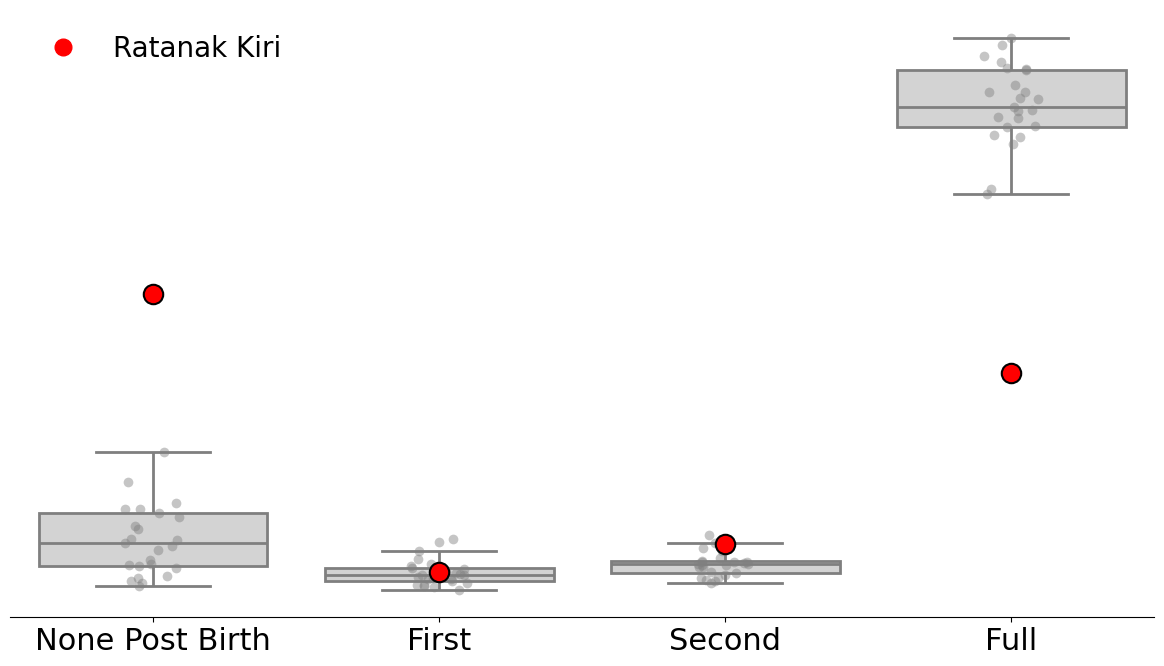

In [10]:
# ---------------------------------------------------
# Vaccination Coverage Confidence Intervals with Ratanak Kiri Highlighted
# ---------------------------------------------------


def test_vaccination_outliers(
    df,
    category_col,
    region_col="Region",
    target_region="Ratanak Kiri",
    alpha=0.05,
    category_order=None,
    weight_col="wt"
):
    """
    Screens whether a target region differs from others using
    binomial tests on within-region weighted proportions.
    Produces a descriptive box/strip plot.
    """
    plt.rcParams.update({'font.size': 18})

    # 1. Weighted counts per region
    counts = (
        df.groupby([region_col, category_col])[weight_col]
        .sum()
        .reset_index(name="Count")
    )
    totals = counts.groupby(region_col)["Count"].sum().reset_index(name="Total")
    counts = counts.merge(totals, on=region_col)
    counts["Proportion"] = counts["Count"] / counts["Total"]

    # 2. Binomial screening test
    results = []
    categories = (
        category_order
        if category_order is not None
        else counts[category_col].unique()
    )

    for cat in categories:
        target = counts[
            (counts[region_col] == target_region) &
            (counts[category_col] == cat)
        ]
        others = counts[
            (counts[region_col] != target_region) &
            (counts[category_col] == cat)
        ]

        if target.empty or others.empty:
            continue

        k = int(target["Count"].iloc[0])
        n = int(target["Total"].iloc[0])
        p_null = others["Count"].sum() / others["Total"].sum()

        test = binomtest(k, n, p=p_null)

        results.append({
            category_col: cat,
            "Target Proportion": k / n,
            "Reference Proportion": p_null,
            "p_value": test.pvalue,
            "Outlier": test.pvalue < alpha
        })

    summary = pd.DataFrame(results)

    if category_order is not None:
        summary[category_col] = pd.Categorical(
            summary[category_col],
            categories=category_order,
            ordered=True
        )
        summary = summary.sort_values(category_col)
        counts[category_col] = pd.Categorical(
            counts[category_col],
            categories=category_order,
            ordered=True
        )

    print("\nOutlier screening results:")
    display(summary.reset_index(drop=True))

    # 3. Visualization
    plt.figure(figsize=(12, 7))

    sns.boxplot(
        data=counts,
        x=category_col,
        y="Proportion",
        color="lightgray",
        fliersize=0,
        linewidth=2
    )
    sns.stripplot(
        data=counts[counts[region_col] != target_region],
        x=category_col,
        y="Proportion",
        color="gray",
        alpha=0.45,
        size=7
    )
    sns.stripplot(
        data=counts[counts[region_col] == target_region],
        x=category_col,
        y="Proportion",
        color="red",
        size=14,
        edgecolor="black",
        linewidth=1.5
    )

    plt.legend(
        handles=[
            plt.Line2D(
                [], [], color="red", marker="o",
                markersize=12, linestyle="", label=target_region
            )
        ],
        frameon=False,
        fontsize=20,
        loc='upper left'
    )

    plt.xlabel("")
    plt.ylabel("")
    plt.title("")
    plt.xticks(fontsize=22)
    plt.yticks([])
    sns.despine(left=True)
    plt.tight_layout()
    if category_col == "Vaccination_Flag":
        plt.savefig("../output/Ratanak_kiri_box_plot_post_birth.png", dpi=300, bbox_inches="tight")
    else:
        plt.savefig("../output/Ratanak_kiri_box_plot_at_birth.png", dpi=300, bbox_inches="tight")                
    
    plt.show()

    return summary.reset_index(drop=True)

# 1. Vaccination at Birth
rk_birth = test_vaccination_outliers(
    df,
    category_col="Vaccination_at_Birth",
    region_col="Region",
    target_region="Ratanak Kiri",
    weight_col="wt"
)

# 2. Post-Birth Vaccination
vacc_order = ["None Post Birth", "First", "Second", "Full"]

rk_post = test_vaccination_outliers(
    df,
    category_col="Vaccination_Flag",
    region_col="Region",
    target_region="Ratanak Kiri",
    category_order=vacc_order,
    weight_col="wt"
)